In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

# Print versions
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.10.0


In [ ]:
# Upload kaggle.json
files.upload()   # upload kaggle.json here

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d mostafaabla/garbage-classification

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
 64% 152M/239M [00:00<00:00, 1.59GB/s]
100% 239M/239M [00:00<00:00, 928MB/s] 


In [ ]:
# Unzip dataset
with zipfile.ZipFile("garbage-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("garbage_dataset")

print("✅ Dataset extracted successfully")

# Check dataset structure
base_dir = "garbage_dataset/garbage_classification"
print("Classes:", sorted(os.listdir(base_dir)))  # Sorted for consistent order
print("Number of classes:", len(os.listdir(base_dir)))

✅ Dataset extracted successfully
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of classes: 12


In [ ]:
# Parameters
img_size = (224, 224)   # MobileNetV2 input size
batch_size = 32

# Data generator with validation split - IMPORTANT: rescale=1./255
datagen = ImageDataGenerator(
    rescale=1./255,  # This is CRUCIAL for matching Streamlit preprocessing
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Training data
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42  # For reproducibility
)

# Validation data
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # Don't shuffle validation data for proper evaluation
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

# Get and save class information for Streamlit
class_indices = train_generator.class_indices
class_labels = list(class_indices.keys())
print("Class indices:", class_indices)
print("Class labels (in order):", class_labels)

# Save class labels to file for Streamlit reference
with open("class_labels.txt", "w") as f:
    for label in class_labels:
        f.write(f"{label}\n")

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.
Training samples: 12415
Validation samples: 3100
Class indices: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
Class labels (in order): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [ ]:
# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available")
    for gpu in gpus:
        print("GPU name:", gpu)
else:
    print("GPU not available")

GPU is available
GPU name: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# Load MobileNetV2 with pre-trained ImageNet weights
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers initially
base_model.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_generator.num_classes, activation='softmax')  # 12 classes
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,500 (9.24 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'garbage_classification_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Starting training...
Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8496 - loss: 0.5014
Epoch 1: val_loss improved from inf to 0.43639, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 184s 473ms/step - accuracy: 0.8496 - loss: 0.5013 - val_accuracy: 0.8542 - val_loss: 0.4364
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8614 - loss: 0.4498
Epoch 2: val_loss improved from 0.43639 to 0.41555, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 181s 467ms/step - accuracy: 0.8615 - loss: 0.4498 - val_accuracy: 0.8687 - val_loss: 0.4155
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8802 - loss: 0.3927
Epoch 3: val_loss improved from 0.41555 to 0.39982, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 180s 464ms/step - accuracy: 0.8802 - loss: 0.3927 - val_accuracy: 0.8723 - val_loss: 0.3998
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8799 - loss: 0.3666
Epoch 4: val_loss improved from 0.39982 to 0.38448, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 181s 467ms/step - accuracy: 0.8799 - loss: 0.3666 - val_accuracy: 0.8755 - val_loss: 0.3845
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8889 - loss: 0.3524
Epoch 5: val_loss improved from 0.38448 to 0.35875, saving model to garbage_classification_model.h5


...

388/388 ━━━━━━━━━━━━━━━━━━━━ 182s 470ms/step - accuracy: 0.9167 - loss: 0.2581 - val_accuracy: 0.8952 - val_loss: 0.3114
Epoch 14/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9163 - loss: 0.2545
Epoch 14: val_loss improved from 0.31144 to 0.30824, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 182s 469ms/step - accuracy: 0.9163 - loss: 0.2545 - val_accuracy: 0.8926 - val_loss: 0.3082
Epoch 15/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9138 - loss: 0.2569
Epoch 15: val_loss did not improve from 0.30824
388/388 ━━━━━━━━━━━━━━━━━━━━ 181s 465ms/step - accuracy: 0.9138 - loss: 0.2568 - val_accuracy: 0.8945 - val_loss: 0.3087
Epoch 16/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9240 - loss: 0.2306
Epoch 16: val_loss improved from 0.30824 to 0.30820, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 183s 472ms/step - accuracy: 0.9240 - loss: 0.2307 - val_accuracy: 0.8955 - val_loss: 0.3082
Epoch 17/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9234 - loss: 0.2362
Epoch 17: val_loss improved from 0.30820 to 0.29493, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 182s 469ms/step - accuracy: 0.9234 - loss: 0.2362 - val_accuracy: 0.9016 - val_loss: 0.2949
Epoch 18/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9255 - loss: 0.2291
Epoch 18: val_loss did not improve from 0.29493
388/388 ━━━━━━━━━━━━━━━━━━━━ 182s 468ms/step - accuracy: 0.9255 - loss: 0.2291 - val_accuracy: 0.9003 - val_loss: 0.3010
Epoch 19/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9194 - loss: 0.2328
Epoch 19: val_loss improved from 0.29493 to 0.29474, saving model to garbage_classification_model.h5


388/388 ━━━━━━━━━━━━━━━━━━━━ 185s 478ms/step - accuracy: 0.9195 - loss: 0.2328 - val_accuracy: 0.9000 - val_loss: 0.2947
Epoch 20/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9298 - loss: 0.2153
Epoch 20: val_loss did not improve from 0.29474
388/388 ━━━━━━━━━━━━━━━━━━━━ 183s 473ms/step - accuracy: 0.9298 - loss: 0.2154 - val_accuracy: 0.8955 - val_loss: 0.3132
Restoring model weights from the end of the best epoch: 19.


In [ ]:
# Load the best model (now with correct filename)
model = load_model('garbage_classification_model.h5')

# Evaluate on validation data
print("Evaluating model...")
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

Evaluating model...
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 417ms/step - accuracy: 0.9155 - loss: 0.2483
Validation Accuracy: 90.06%
Validation Loss: 0.2960


In [ ]:
# Add this after preprocessing, before prediction
print(f"Image array shape: {img_array.shape}")
print(f"Image array range: [{img_array.min()}, {img_array.max()}]")
print(f"Image array dtype: {img_array.dtype}")

NameError: name 'img_array' is not defined

In [ ]:
# Predict on validation data
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Classification report
print("\nClassification Report:\n")
report = classification_report(
    val_generator.classes,
    y_pred,
    target_names=class_labels
)
print(report)

# Save report as text file
with open("classification_report.txt", "w") as f:
    f.write(report)

97/97 ━━━━━━━━━━━━━━━━━━━━ 50s 419ms/step

Classification Report:

              precision    recall  f1-score   support

     battery       0.96      0.91      0.93       189
  biological       0.94      0.95      0.95       197
 brown-glass       0.86      0.82      0.84       121
   cardboard       0.95      0.85      0.90       178
     clothes       0.98      0.98      0.98      1065
 green-glass       0.92      0.78      0.84       125
       metal       0.70      0.80      0.75       153
       paper       0.85      0.91      0.88       210
     plastic       0.66      0.80      0.72       173
       shoes       0.95      0.97      0.96       395
       trash       0.88      0.88      0.88       139
 white-glass       0.69      0.53      0.60       155

    accuracy                           0.90      3100
   macro avg       0.86      0.85      0.85      3100
weighted avg       0.90      0.90      0.90      3100



In [ ]:
print(train_generator.class_indices)

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


In [ ]:
# Confusion matrix
cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as confusion_matrix.png")

NameError: name 'y_pred' is not defined

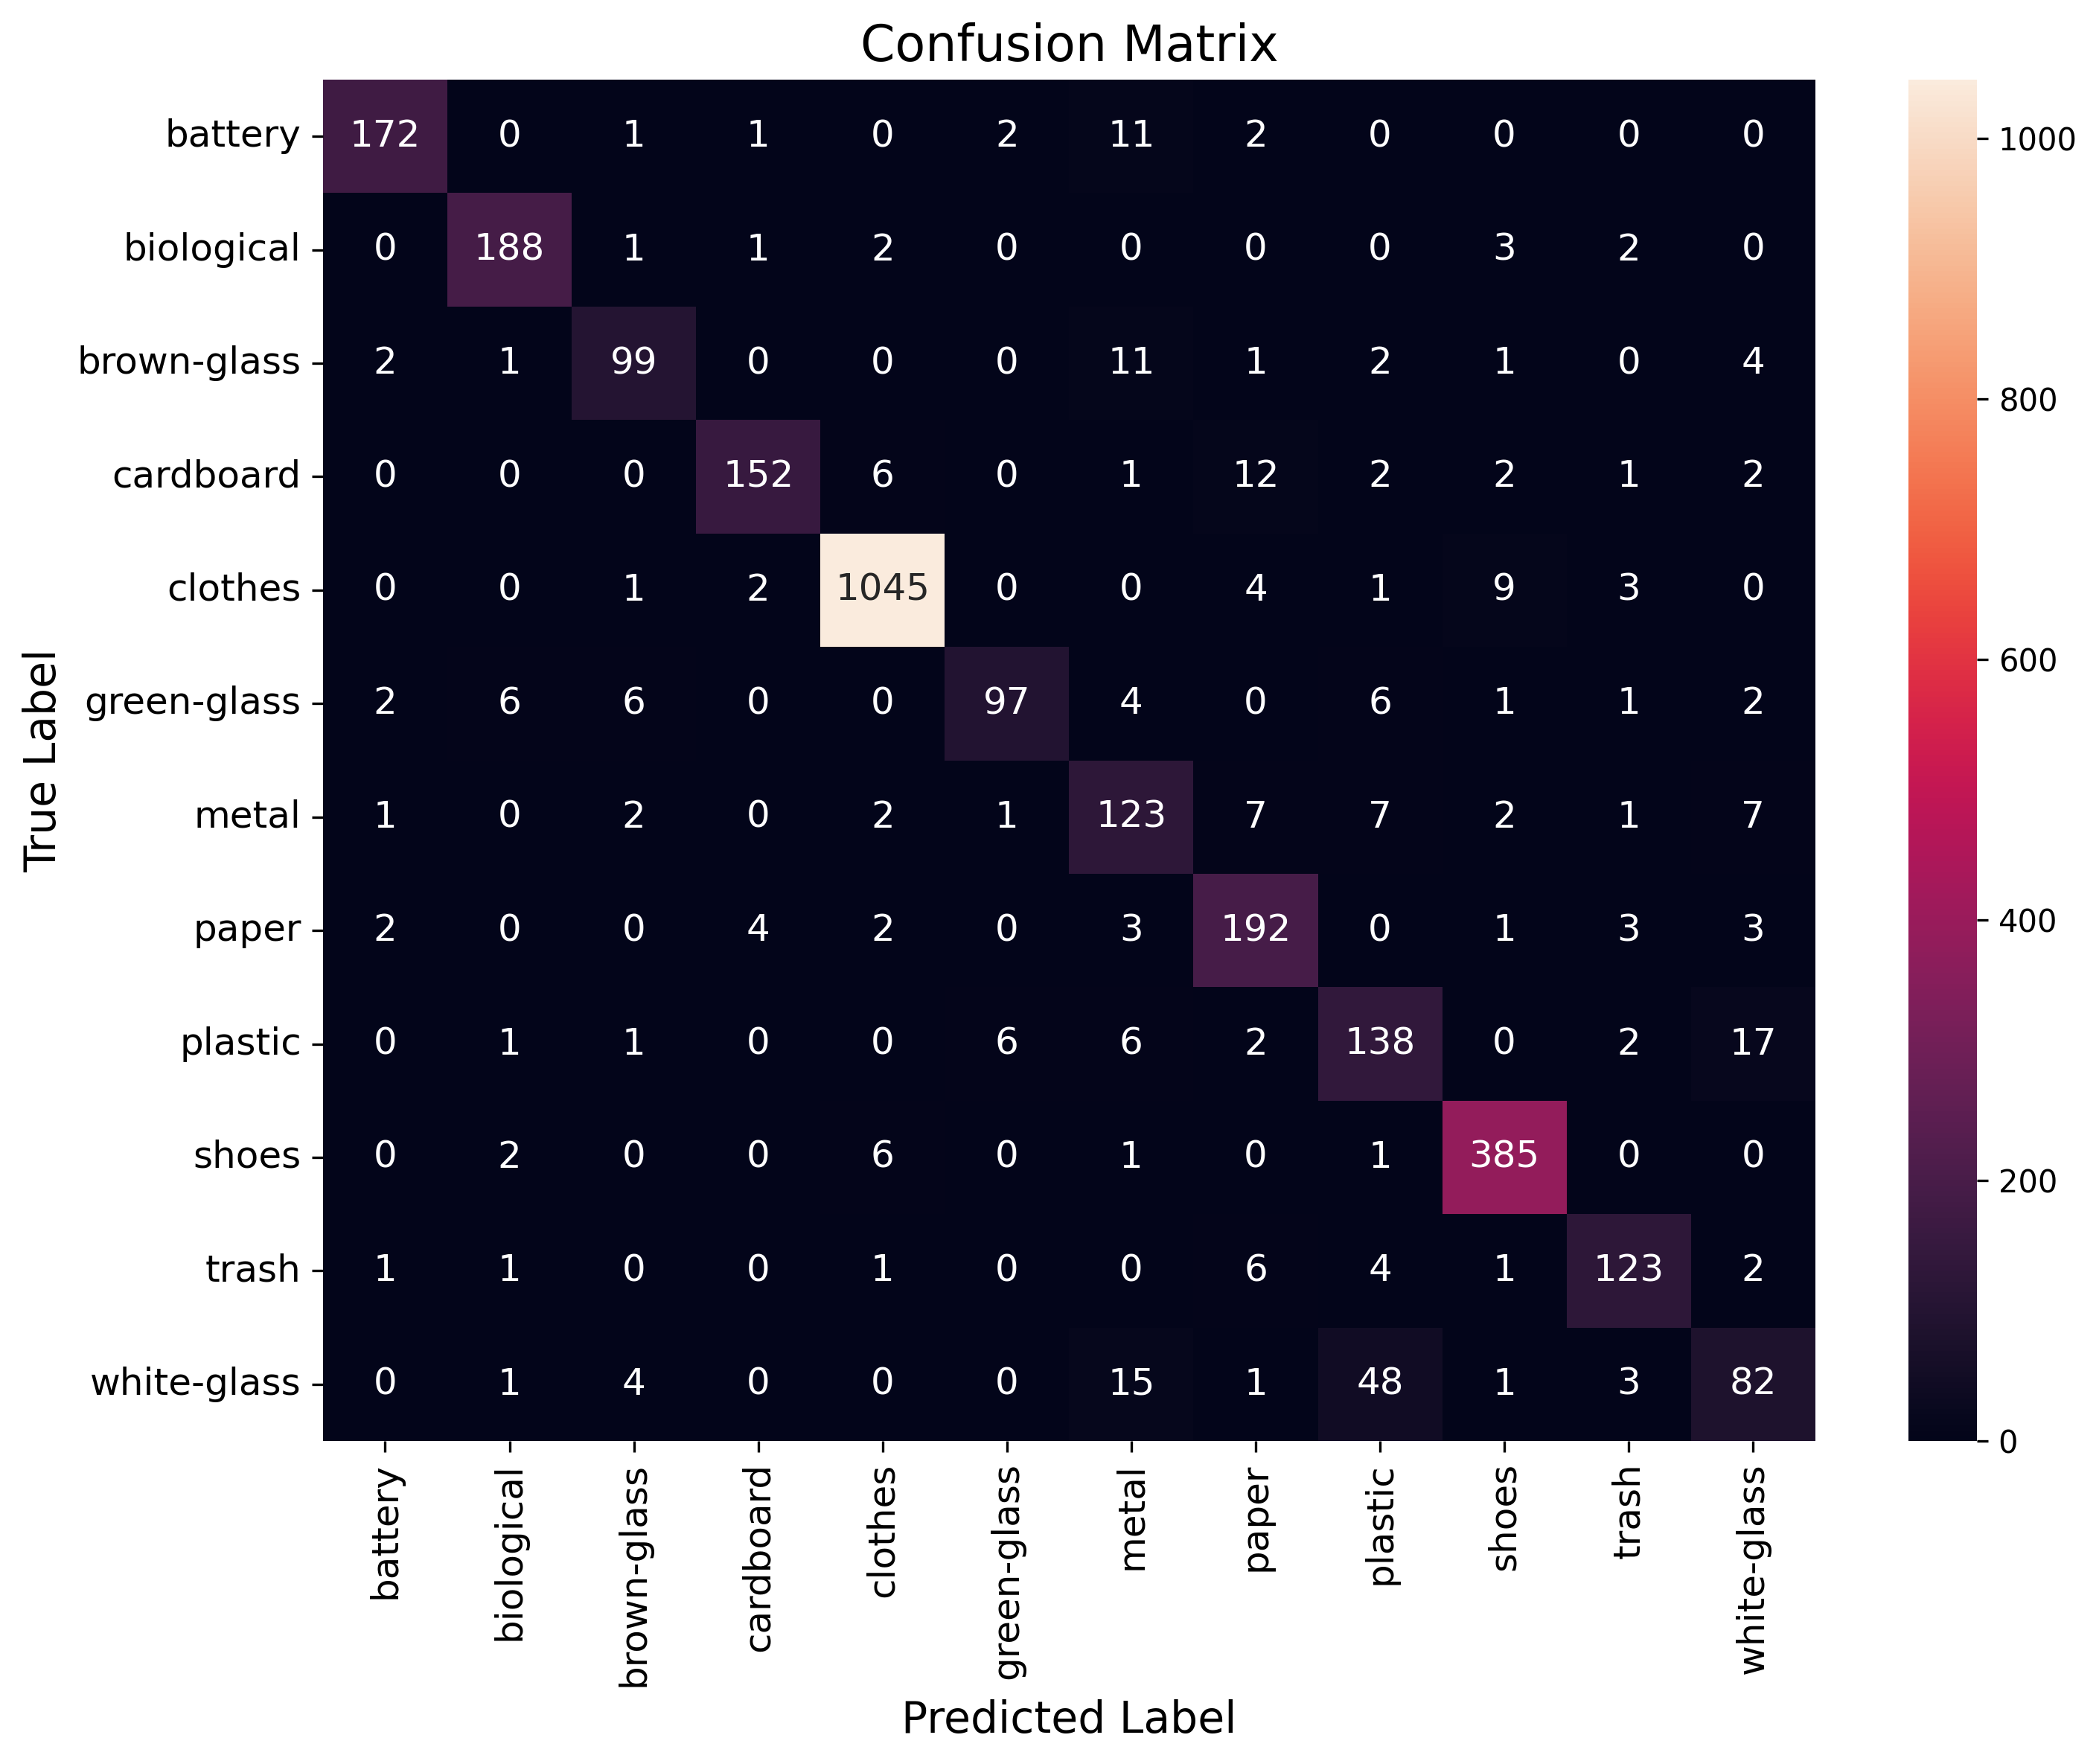

Confusion matrix saved as confusion_matrix.tiff and confusion_matrix.eps


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(val_generator.classes, y_pred)

# Bigger figure + high DPI
plt.figure(figsize=(10, 8), dpi=300)

# Heatmap with bigger fonts
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": 12},
    cbar=True
)

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

# Save in IEEE formats
plt.savefig("confusion_matrix.tiff", format="tiff", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix.eps", format="eps", bbox_inches="tight")

plt.show()

print("Confusion matrix saved as confusion_matrix.tiff and confusion_matrix.eps")

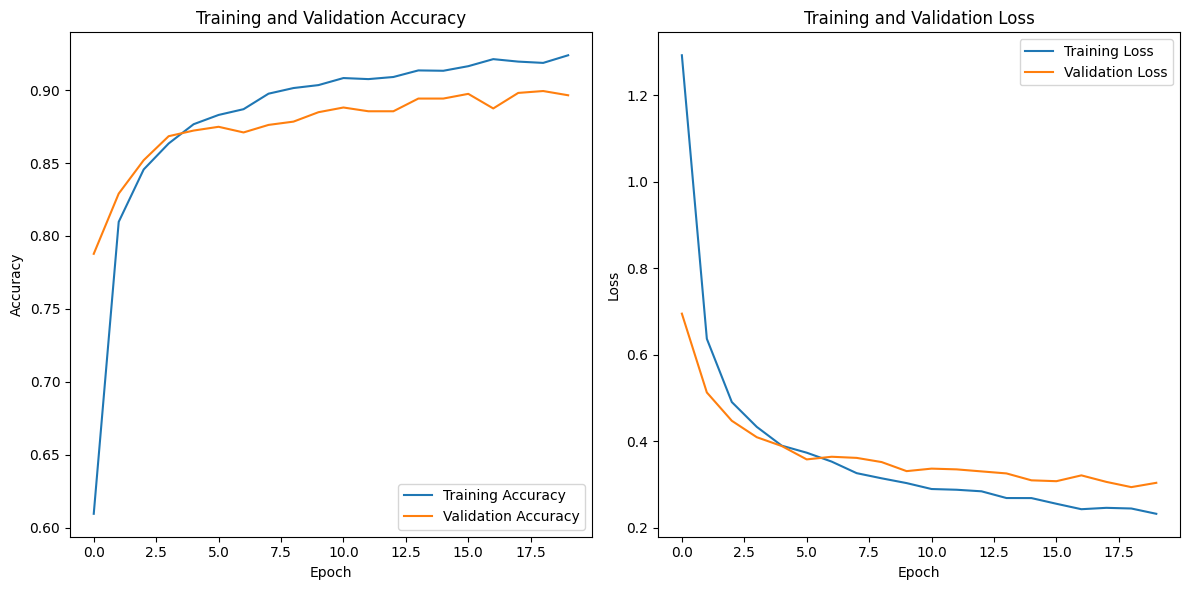

Training & Validation curves saved as training_validation_curves.png


In [ ]:
# Training history plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,6))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.savefig("training_validation_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("Training & Validation curves saved as training_validation_curves.png")

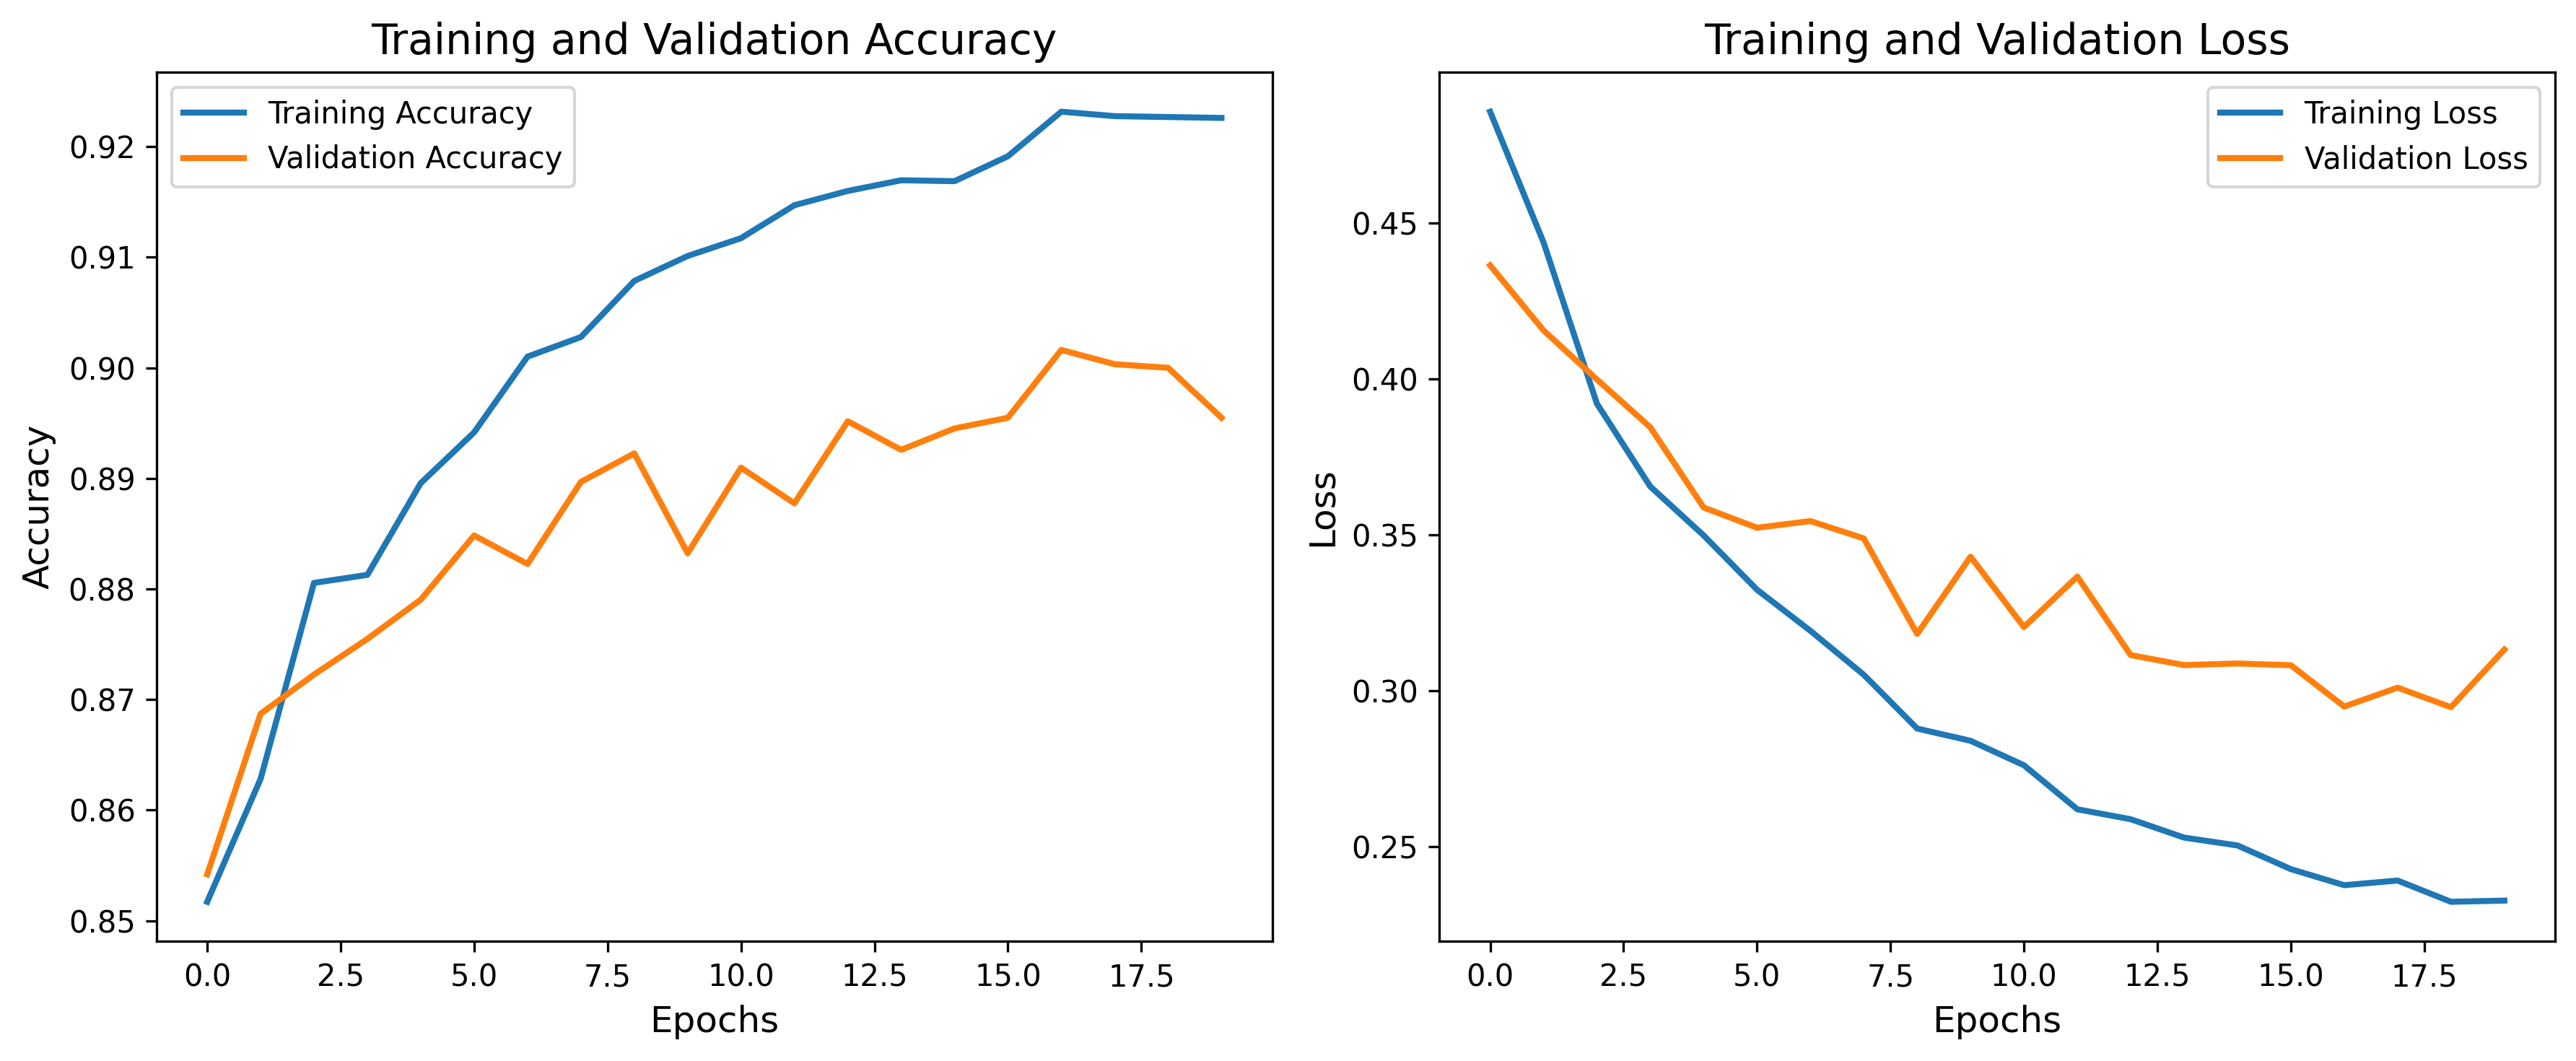

Saved as training_validation_curves.tiff (IEEE + MS Word ready)


In [ ]:
# Training history plots (IEEE quality)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# High quality figure
plt.figure(figsize=(12, 5), dpi=300)

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", linewidth=2)
plt.plot(epochs_range, val_acc, label="Validation Accuracy", linewidth=2)
plt.title("Training and Validation Accuracy", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", linewidth=2)
plt.plot(epochs_range, val_loss, label="Validation Loss", linewidth=2)
plt.title("Training and Validation Loss", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Save for MS Word + IEEE
plt.savefig("/content/training_validation_curves.tiff",
            format="tiff",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Saved as training_validation_curves.tiff (IEEE + MS Word ready)")

In [ ]:
# Save full Keras model
model.save("garbage_classification_model.h5")
print("Model saved as garbage_classification_model.h5")

# Convert to TensorFlow Lite for smaller size
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("garbage_classification_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model also saved as garbage_classification_model.tflite (compressed for deployment)")

NameError: name 'model' is not defined

In [ ]:
from google.colab import files

files.download("garbage_classification_model.tflite")  # smaller, good for GitHub & Streamlit
files.download("garbage_classification_model.h5")     # optional, local testing
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Path to your test image
img_path = "/content/hello.jpeg"  # change to your image file

# Output folder for PPT-ready images
output_dir = "predicted_images"
os.makedirs(output_dir, exist_ok=True)

# Class labels
class_labels = list(train_generator.class_indices.keys())

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_idx = np.argmax(pred)
class_name = class_labels[class_idx]
confidence = np.max(pred)

# Display and save
plt.imshow(img)
plt.title(f"Predicted: {class_name} ({confidence*100:.2f}%)")
plt.axis('off')

# Save the image with prediction as PNG
save_path = os.path.join(output_dir, os.path.basename(img_path))
plt.savefig(save_path)
plt.close()

print(f"Predicted image saved as '{save_path}' for PPT")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Predicted image saved as 'predicted_images/hello.jpeg' for PPT


In [ ]:
!md5sum garbage_classification_model.h5

c62fab0f8b9adc3e14710032f66c3431  garbage_classification_model.h5
